In [54]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

In [55]:
model= YOLO("/Users/mehmetdegirmenci/Desktop/Microsoft proje/runs/uav_detector-5/weights/best.pt")


In [56]:
import os

test_dir = "/Users/mehmetdegirmenci/Desktop/Microsoft proje/dataset/test"
seq = os.listdir(test_dir)[0]  # İlk dizini alıyoruz (örneğin "seq1")
img_dir = os.path.join(test_dir, seq)
img_name = sorted(os.listdir(img_dir))[0]  # İlk görüntüyü alıyoruz  sorted ile sıralıyoruz
img_path = os.path.join(img_dir, img_name)

print(f"Test görüntüsü: {img_path}")


Test görüntüsü: /Users/mehmetdegirmenci/Desktop/Microsoft proje/dataset/test/20190925_200805_1_2/000001.jpg


In [57]:
results = model(img_path)



image 1/1 /Users/mehmetdegirmenci/Desktop/Microsoft proje/dataset/test/20190925_200805_1_2/000001.jpg: 256x320 1 uav, 184.1ms
Speed: 39.0ms preprocess, 184.1ms inference, 61.5ms postprocess per image at shape (1, 3, 256, 320)


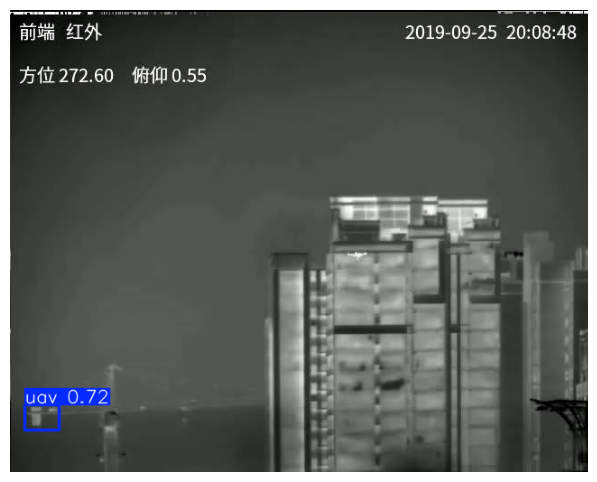

In [58]:
import matplotlib.pyplot as plt

annotated = results[0].plot()  # İlk sonuçtaki anotasyonu alıyoruz
annotated_rgb = annotated[:, :, ::-1]  # BGR'den RGB'ye dönüştürme
plt.figure(figsize=(10, 6))
plt.imshow(annotated_rgb)
plt.axis("off")
plt.show()

In [59]:
boxes = results[0].boxes
print("Kaç tane tespit:", len(boxes))                                  
print("Koordinatlar (x1,y1,x2,y2):", boxes.xyxy)                       
print("Güven skoru:", boxes.conf)                                      
print("Sınıf:", boxes.cls)

Kaç tane tespit: 1
Koordinatlar (x1,y1,x2,y2): tensor([[ 16.0284, 437.0436,  54.0801, 465.4497]])
Güven skoru: tensor([0.7225])
Sınıf: tensor([0.])



0: 256x320 1 uav, 33.3ms
1: 256x320 1 uav, 33.3ms
2: 256x320 (no detections), 33.3ms
3: 256x320 1 uav, 33.3ms
4: 256x320 1 uav, 33.3ms
Speed: 0.4ms preprocess, 33.3ms inference, 0.2ms postprocess per image at shape (1, 3, 256, 320)


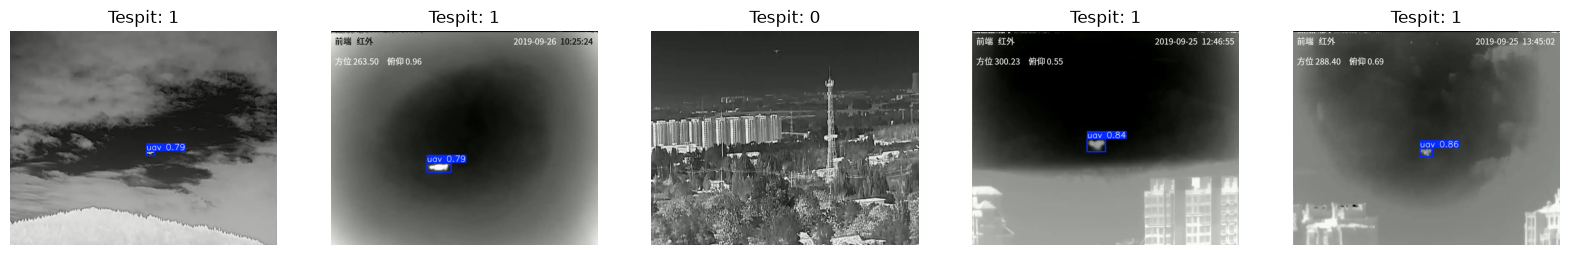

In [60]:
import random                                                          
                                                                         
seq_list = os.listdir(test_dir)      # test dizinindeki tüm sequence'leri alıyoruz       
test_images = []  # test imageları almak için boş bir liste oluşturuyoruz                                                       
                  
for seq in random.sample(seq_list, 5):   # rastgele 5 sequence         
    img_dir = os.path.join(test_dir, seq)
    frames = sorted(os.listdir(img_dir))                               
    frames = [f for f in frames if f.endswith(".jpg")]                 
    if frames:  # frame varsa, ilk frame'i alıyoruz                          
       test_images.append(os.path.join(img_dir, frames[0]))           
                                                                       
results_multi = model(test_images)      # 5 görüntüyü de modele veriyoruz
                                                                         
fig, axes = plt.subplots(1, 5, figsize=(20, 4))  # 5 görüntü için subplot oluşturuyoruz                      
for i, (r, ax) in enumerate(zip(results_multi, axes)):
    ax.imshow(r.plot()[:, :, ::-1])                                    
    ax.axis("off")                                                     
    ax.set_title(f"Tespit: {len(r.boxes)}") 
plt.show() 

In [61]:
import sys
sys.path.append("/Users/mehmetdegirmenci/Desktop/Microsoft proje")

from src.kalman import kalmanFilter

tracker = kalmanFilter(100, 200)

pred = tracker.predict()
print("Tahmin : " , pred)

updated = tracker.update(105 , 203)
print("Güncelleme sonrası:", updated)

pred2 = tracker.predict()
print("2. Tahmin : " , pred2)


Tahmin :  [        100         200]
Güncelleme sonrası: [     104.98      202.99]
2. Tahmin :  [     107.46      204.48]


In [62]:
""" 
Tahmin :  [100. 200.]  ilk başlangıç noktası zaten 0 olacak
Güncelleme sonrası: [104.97512562 202.98507537]  
2. Tahmin :  [107.46256405 204.47753843]

"""

' \nTahmin :  [100. 200.]  ilk başlangıç noktası zaten 0 olacak\nGüncelleme sonrası: [104.97512562 202.98507537]  \n2. Tahmin :  [107.46256405 204.47753843]\n\n'

In [63]:
tracker2 = kalmanFilter(100, 200)                                      
                                                                         
# YOLO görüyor
tracker2.predict()                                                         
tracker2.update(105, 203)

tracker2.predict()
tracker2.update(110, 206)                                              

tracker2.predict()
tracker2.update(115, 209)                                              
                                                                         
print("YOLO kayboldu, sadece tahminle devam:")
for i in range(3):                                                     
    pred = tracker2.predict()
    print(f"  Frame {i+1} tahmini:", pred) 

YOLO kayboldu, sadece tahminle devam:
  Frame 1 tahmini: [     119.95      211.97]
  Frame 2 tahmini: [     124.93      214.96]
  Frame 3 tahmini: [      129.9      217.94]


In [64]:
 # !pip install scipy

In [65]:
import sys
sys.path.append("/Users/mehmetdegirmenci/Desktop/Microsoft proje")

from src.association import associate

trackers = [(100, 200), (400, 300)]
detections = [(102,198),(405,297),(250,250)]

matches, unmatched = associate(trackers,detections)
 

print("Eşleşmeler:", matches)                                          
print("Eşleşmeyen tespitler:", unmatched) 

Eşleşmeler: [(np.int64(0), np.int64(0)), (np.int64(1), np.int64(1))]
Eşleşmeyen tespitler: [2]


In [66]:
from src.tracker import Tracker

tracker = Tracker(max_missing=3)

# Frame 1: 2 drone görüldü                                             
tracks = tracker.update([(100, 200), (400, 300)])                      
print("Frame 1:", [(t.id, t.state.name) for t in tracks])              
                                                                         
# Frame 2: 2 drone hala görünüyor                         
tracks = tracker.update([(105, 203), (404, 298)])                      
print("Frame 2:", [(t.id, t.state.name) for t in tracks])
                                                                         
# Frame 3: 1. drone kayboldu                              
tracks = tracker.update([(410, 295)])                                  
print("Frame 3:", [(t.id, t.state.name) for t in tracks])
                                                                         
# Frame 4: hala kayıp                                     
tracks = tracker.update([(415, 292)])
print("Frame 4:", [(t.id, t.state.name) for t in tracks])              
                                              
# Frame 5: hala kayıp                                                  
tracks = tracker.update([(420, 289)])                     
print("Frame 5:", [(t.id, t.state.name) for t in tracks])              
                                              
# Frame 6: hala kayıp (max_missing=3 aşıldı)                           
tracks = tracker.update([(425, 286)])                     
print("Frame 6:", [(t.id, t.state.name) for t in tracks])              

Frame 1: [(0, 'KILITLI'), (1, 'KILITLI')]
Frame 2: [(0, 'KILITLI'), (1, 'KILITLI')]
Frame 3: [(0, 'TAHMIN'), (1, 'KILITLI')]
Frame 4: [(0, 'TAHMIN'), (1, 'KILITLI')]
Frame 5: [(0, 'TAHMIN'), (1, 'KILITLI')]
Frame 6: [(1, 'KILITLI')]


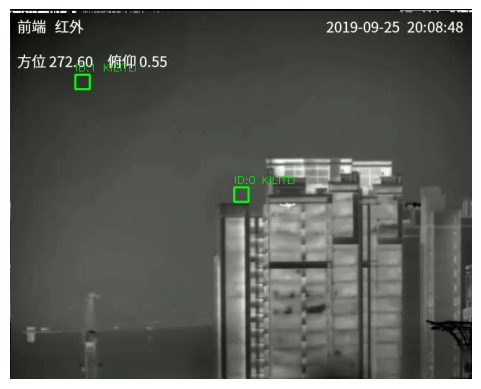

In [67]:
from src.visualize import draw_tracks
from src.tracker import Tracker
from PIL import Image
import numpy as np

img = np.array(Image.open(img_path).convert("RGB"))
frame = img[:, :, :: -1].copy() # RGB -> BGR

tracker2 = Tracker(max_missing=3)
tracks = tracker2.update([(320,256), (100, 100)])

result = draw_tracks(frame , tracks)

plt.imshow(result[:,:,::-1])
plt.axis("off")
plt.show()






image 1/1 /Users/mehmetdegirmenci/Desktop/Microsoft proje/dataset/test/20190925_200805_1_2/000001.jpg: 256x320 1 uav, 33.9ms
Speed: 0.5ms preprocess, 33.9ms inference, 0.3ms postprocess per image at shape (1, 3, 256, 320)


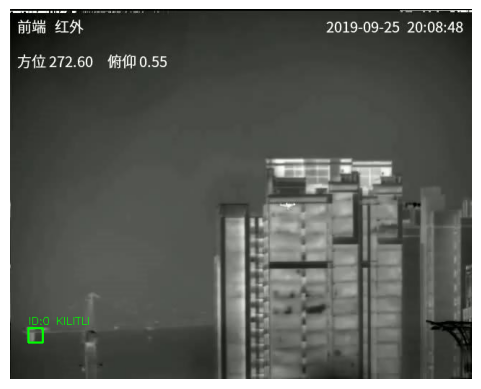

Tespit: 1 Track: 1


In [68]:
from ultralytics import YOLO                                           
from src.tracker import Tracker                                        
from src.visualize import draw_tracks                                  
import cv2, numpy as np                 
from PIL import Image                                                  
import matplotlib.pyplot as plt                                        
  
model = YOLO("/Users/mehmetdegirmenci/Desktop/Microsoft proje/runs/uav_detector-5/weights/best.pt")                    
tracker3 = Tracker(max_missing=3)                         
                                              
# Görüntüyü yükle                                                      
img = np.array(Image.open(img_path))
frame = img[:, :, ::-1].copy()  # RGB → BGR                            
                                                            
# YOLO tespiti                                                         
results = model(img_path, conf=0.3)                                    
boxes = results[0].boxes                    
                                                                         
# YOLO çıktısını (x_center, y_center) listesine çevir     
detections = []                                                        
for box in boxes.xyxy:
    x1, y1, x2, y2 = box.tolist()                                      
    cx = (x1 + x2) / 2                                    
    cy = (y1 + y2) / 2                                                 
    detections.append((cx, cy))                                        
                                          
# Tracker güncelle                                                     
tracks = tracker3.update(detections)                                   
  
  # Çiz                                                                  
result = draw_tracks(frame, tracks)                       
plt.imshow(result[:, :, ::-1])              
plt.axis("off")                         
plt.show()
                                                                         
print("Tespit:", len(detections), "Track:", len(tracks))


image 1/1 /Users/mehmetdegirmenci/Desktop/Microsoft proje/dataset/test/3700000000002_130905_1/000337.jpg: 256x320 (no detections), 34.4ms
Speed: 0.4ms preprocess, 34.4ms inference, 0.2ms postprocess per image at shape (1, 3, 256, 320)

image 1/1 /Users/mehmetdegirmenci/Desktop/Microsoft proje/dataset/test/20190926_111509_1_4/000614.jpg: 256x320 1 uav, 28.0ms
Speed: 0.4ms preprocess, 28.0ms inference, 0.3ms postprocess per image at shape (1, 3, 256, 320)

image 1/1 /Users/mehmetdegirmenci/Desktop/Microsoft proje/dataset/test/20190925_111757_1_1/000615.jpg: 256x320 1 uav, 27.4ms
Speed: 0.4ms preprocess, 27.4ms inference, 0.3ms postprocess per image at shape (1, 3, 256, 320)

image 1/1 /Users/mehmetdegirmenci/Desktop/Microsoft proje/dataset/test/20190925_124612_1_4/000785.jpg: 256x320 2 uavs, 27.5ms
Speed: 0.4ms preprocess, 27.5ms inference, 0.3ms postprocess per image at shape (1, 3, 256, 320)

image 1/1 /Users/mehmetdegirmenci/Desktop/Microsoft proje/dataset/test/20190926_134054_1_3/00

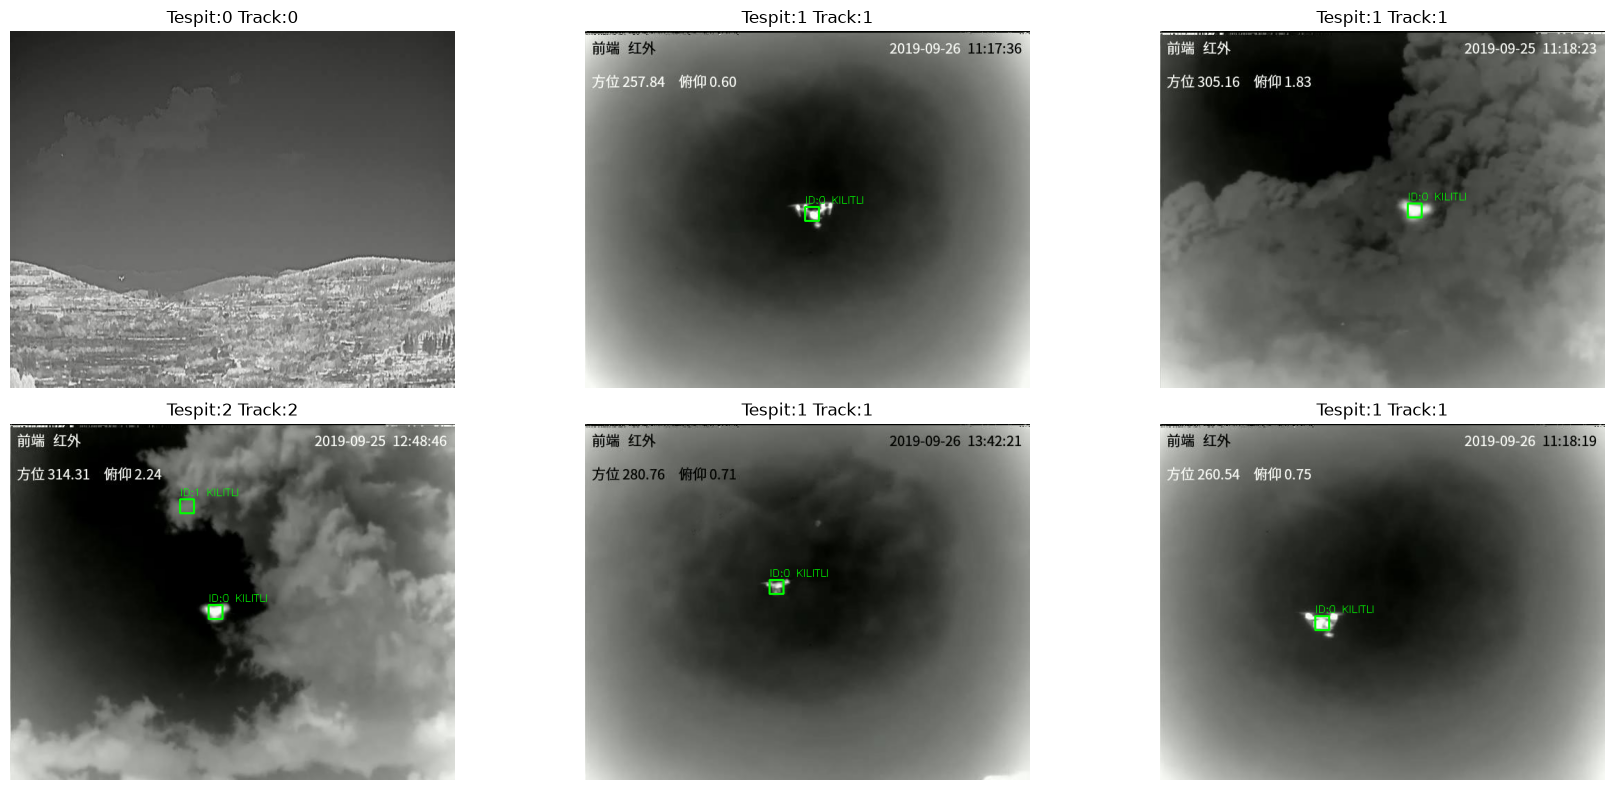

In [69]:
import random                                                          
                                                                         
fig, axes = plt.subplots(2, 3, figsize=(18, 8))                        
                                                                         
for ax in axes.flat:                                                   
    seq = random.choice([s for s in os.listdir(test_dir) if not        
s.startswith(".")])                         
    img_dir = os.path.join(test_dir, seq)                              
    frames = sorted([f for f in os.listdir(img_dir) if                 
f.endswith(".jpg")])                                                   
    random_frame = random.choice(frames)                               
    path = os.path.join(img_dir, random_frame)                         
                                                            
    res = model(path, conf=0.3)
    boxes = res[0].boxes                                               
  
    detections = []                                                    
    for box in boxes.xyxy:                                
        x1, y1, x2, y2 = box.tolist()
        detections.append(((x1+x2)/2, (y1+y2)/2))                      
                                              
    t = Tracker(max_missing=3)                                         
    tracks = t.update(detections)                         
                                                                         
    img = np.array(Image.open(path))
    frame = img[:, :, ::-1].copy()                                     
    result = draw_tracks(frame, tracks)                   
                                              
    ax.imshow(result[:, :, ::-1])       
    ax.axis("off")
    ax.set_title(f"Tespit:{len(detections)} Track:{len(tracks)}")      
                                              
plt.tight_layout()                                                     
plt.show()

In [70]:
!pip install motmetrics

101373.40s - pydevd: Sending message related to process being replaced timed-out after 5 seconds



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [71]:
from src.evaluate import evaluate                           
from src.tracker import Tracker
import os                                                              
                                                                         
# 3 sequence ile hızlı test                                            
test_dir = "/Users/mehmetdegirmenci/Desktop/Microsoft proje/dataset/test"                                              
seqs = sorted([s for s in os.listdir(test_dir) if not                  
s.startswith(".")])[:3]                                                
                                                                         
sequences = [                                                          
    (f"{test_dir}/{s}", f"{test_dir}/{s}/IR_label.json")  
    for s in seqs                                                      
]
                                                                         
tracker = Tracker(max_missing=3)                          
summary = evaluate(tracker, model, sequences, conf=0.3)

          mota      idf1  num_switches
eval  0.345066  0.083525            45
FPS: 34.0


In [72]:
# ! pip install sahi

In [53]:
from src.detector import load_model, detect

sahi_model = load_model(
    "/Users/mehmetdegirmenci/Desktop/Microsoft proje/runs/uav_detector-5/weights/best.pt",
    conf=0.3
)

dets = detect(
    sahi_model,
    img_path
)

print(f"Tespit sayısı : {len(dets)}")

for d in dets:
    print(f"  x:{d[0]:.1f} y:{d[1]:.1f} conf:{d[2]:.2f}")

TypeError: AutoDetectionModel.from_pretrained() missing 1 required positional argument: 'model_type'